# Hugging Face Reasoning LLM: A Guide To Model Selection and Leaderboard Insights

## Project Overview  
In this Project, we will explore the power of reasoning models such as DeepSeek to perform sentiment analysis on news data and classify them with reason.  
In Previous task, we explored running open-source models for document Q&A. Now, lets dive into models known for stronger **reasoning** capabilities and apply them to a real-world task: analyzing financial news.  
We'll use a model from the **DeepSeek** family, known for their strength in coding and instruction following, which often translates to better step-by-step reasoning. We won't just classify news as positive, negative, or neutral; we'll ask the model to explain its reasoning and provide a tag for the news.  
**What We'll Build**:  
A system that:
1. Loads financial news headlines and descriptions from a Hugging Face dataset.
2. Use a DeepSeek model (like `deepseek-coder-1.3b-instruct`) to analyze the news.
3. Outputs not just the sentiment classification (Positive, Negative, Neutral) but also a reasoning trace explaining why it reached that conclusion.
4. Presents this analysis in a simple Gradio interface.

## Learning Outcomes  
1. Work with reasoning LLMs, such as DeepSeek, that require logical, step-by-step thinking and understand how these models differ from general-purpose chatbots.
2. Explore how to use the Hugging Face datasets library to efficiently load, preprocess and manage datasets from the Hub.
3. Develop prompting strategeis for structured responses that guide models to generate outputs in a specific format (e.g., reasoning steps followed by classification.)
4. Gain skills in parsing model outputs to extract relevant elements, such as intermedicate reasoning and final answers, from generated text.
5. Apply LLMs to classification tasks that are typically handled by traditional classifiers, with the added advantages of greter transparency and explainability.
6. Learn how to navigate Hugging Face leaderboards to evaluate the performance of open-and-closed-source models.
7. Apply a framework to choose the right LLM for you business.

### Explore Hugging Face Datasets Library and Install Key Libraries  
As Usual, we begin by installing the necessary libraries. This time, we're adding the `datasets` library to easily load data from the Hugging Face Hub. We'll also repeat the Hugging Face Login step, which is good practice.  
**Installing Libraries**:  
- `transfromers`, `accelerate`, `bitsandbytes`, `torch`: For Loading and runnig on our DeepSeek model efficiently.
- `datasets`: To load the financial news dataset.
- `gradio`: For building the UI.

- **Link to Datasets Library on Hugging Face: https://huggingface.co/datasets**

In [1]:
print("Installing necessary Libraries...")

# Transformers: Lets you easily use powerful pre-trained AI models for task like text generation, translation, or classification
# Accelerate: Helps you run and trainmodels efficiently across CPUs, GPUs.
# BitsAndBytes: Reduces the size of large models using quantization so they can fit and run on limited hardware and GPU acceleration.
# Torch (PyTorch): A deep learning library used to build, train, and run neural networks using tensors and GPU acceleration.

# Added 'datasets' to the list.
!pip install -q Transformers accelerate bitsandbytes torch datasets gradio

print("Libraries installed successfully!")

Installing necessary Libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.4 MB/s eta 0:00:00
Libraries installed successfully!


In [2]:
# Hugging Face Login
import os
from huggingface_hub import login, notebook_login

print("Attempting Hugging FGace Login....")
notebook_login()
print("Login successful(or token already present)")

Attempting Hugging FGace Login....
Login successful(or token already present)


In [3]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from datasets import load_dataset
import gradio as gr
from IPython.display import display, Markdown
import random

# Check for GPU availability
if torch.cuda.is_available():
  print(f"GPU Detected : {torch.cuda.get_device_name(0)}")
  torch.set_default_device('cuda')
  print(f"PyTorch default device set to CUDA (GPU).")
else:
  print("Warning: No GPU detected. Perfromance will be very slow.")
  print("Go to Colab Runtime > Change Runtime Type > select GPU.")

GPU Detected : Tesla T4
PyTorch default device set to CUDA (GPU).


In [4]:
# Helper Function for markdown display
def print_markdown(text):
  """
  Displays text as markdown."""
  display(Markdown(text))

### Load Financial News Dataset From Hugging Face Hub  
We'll use the Hugging Face `datasets` library to load the `PaulAdversarial/all_news_finance_sm_1h2023` datasets directly from the Hub. This library makes accessing and manipulating large datasets incredibly convenient.  
**Steps**:  
1. Use `load_dataset("dataset_name")` to download and cache the dataset.
2. Inspect the dataset structure and featrues (columns)
3. Select the relevant columns ('title' and 'description') for our analysis.
4. Combine the title and description into a single text input for the LLM.

In [8]:
dataset_id = "gopalkalpande/bbc-news-summary"
print(f"Loading dataset : {dataset_id}...")

# Load dataset (will download if not cached)
# We might only need the 'train' split, specify split = 'train' if needed
# The datatpe of news_dataset is datasets.Dataset (from the datasets library by Hugging Face).

news_dataset = load_dataset(dataset_id, split = 'train')
print("Dataset loaded successfully!")

Loading dataset : gopalkalpande/bbc-news-summary...


README.md:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

bbc-news-summary.csv:   0%|          | 0.00/7.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2224 [00:00<?, ? examples/s]

Dataset loaded successfully!


In [9]:
# Let's Inpspect the dataset
news_dataset

Dataset({
    features: ['File_path', 'Articles', 'Summaries'],
    num_rows: 2224
})

In [10]:
# Let's display the features (columns and their types)
print("\nDataset Features")
print(news_dataset.features)


Dataset Features
{'File_path': Value('string'), 'Articles': Value('string'), 'Summaries': Value('string')}


In [11]:
# Let's view the datasets as Pandas DataFrame
news_dataset.to_pandas()

,File_path,Articles,Summaries
0,politics,Budget to set scene for election..Gordon Brown...,- Increase in the stamp duty threshold from £6...
1,politics,Army chiefs in regiments decision..Military ch...,"""They are very much not for the good and will ..."
2,politics,Howard denies split over ID cards..Michael How...,Michael Howard has denied his shadow cabinet w...
3,politics,Observers to monitor UK election..Ministers wi...,The report said individual registration should...
4,politics,Kilroy names election seat target..Ex-chat sho...,"UKIP's leader, Roger Knapman, has said he is g..."
...,...,...,...
2219,business,India opens skies to competition..India will a...,India will allow domestic commercial airlines ...
2220,business,Yukos bankruptcy 'not US matter'..Russian auth...,Yukos says a US court was entitled to declare ...
2221,business,Survey confirms property slowdown..Government ...,House prices were 11.8% higher on the year in ...
2222,business,High fuel prices hit BA's profits..British Air...,"Rod Eddington, BA's chief executive, said the ..."


In [14]:
# Let's prepare the data for the LLM
# We'll combine title and description for the input text
def combine_news_text(example):
  # Handle potential None values gracefully
  title = example.get("title", "") or ""
  description = example.get("description", "") or ""

  # Add a separator for clarity
  return {"full_text": f"Title: {title}\nDescription: {description}"}

In [15]:
# Let's apply the function to combine the 'title' and 'description' into 'full_text'
# This uses map, which is efficientfor datasets

news_dataset = news_dataset.map(combine_news_text)
print(f"\n--- Sample Data with 'full_text' --- \n{news_dataset[0]}")

Map:   0%|          | 0/2224 [00:00<?, ? examples/s]


--- Sample Data with 'full_text' --- 
{'File_path': 'politics', 'Articles': 'Budget to set scene for election..Gordon Brown will seek to put the economy at the centre of Labour\'s bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from £60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour...Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about £2bn to spare...- Increase in the stamp duty threshold from £60,000. - A freeze on petrol duty. - An extension of tax credit scheme for poorer families. - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties\' general el

In [16]:
# Let's display the full_text of the first sample
print(news_dataset[0]['full_text'])

Title: 
Description: 


### Load and Test DeepSeek Reasoning Model  
Now, let's load our chosen, "reasoning" model. We're using `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B` which excels at following complex instructions and performing logical steps, which is useful for our task of generating a reasoned sentiment analysis.  
**Why DeepSeek for this Task?**  
- **Instruction Following**: Good at adhering to complex prompt, like our request for both reasoning and classification in a specific format.
- **Logical Steps**: Its training helps in breaking down the analysis into steps (the reasoning trace).
- **Colab Friendly**: The 1.5B parameter size is manageable within the free tier GPU memory limits when using 4-bit quantization.  
We'll load it using the same `transformers` components (`AutoTokenizer`, `AutoModelForCausalLM`, `pipeline`) and 4-bit quantization (`load_in_4bit=True`) as in the previous project.

### DeespSeek Models: RL Vs. SFT  
- Unlike OpenAI's GPT models, which typically rely on supervised fine-tuning (SFT) before reinforcement learning (RL), DeepSeek models take a different path.
- They apply RL directly to the base model wihtout using SFT as a starting point.
- This unique training strategy enables the model to naturally develop advanced reasoning skills, such as chain-of-thought reasoning, self-verification and reflection. DeepSeek models generate more thoughtful, step-by-step solutions to complex problems, representing a significant breakthrough in the field of AI.


Let's explore the model: https://huggingface.co/deepseek-ai/deepseek-coder-1.3b-instruct

In [18]:
!pip install -q bitsandbytes accelerate transformers

In [23]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# Lets choose our smaller DeepSeek model, which is suitable for Google Colab and reasoning tasks.
model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
print(f"Loading model: {model_id}")
print("This may take a few minutes....")



bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)
# AutoModelForCausalLM.from_pretrained(...): Loads a pre-trained language model for tasks like text generation (e.g., ChatGPT-llike behavior)
# model_id: The name or path of the model you want to load from Hugging Face (like "meta-llama/Lalam-3-8b")
# torch_dtype = "auto": Automatically chooses the best data type (like float16 or float32) based on your hardaware for efficiency
# load_in_4bit = True: Loads the model in 4-bit precision to save memory and run on limited hardware like freee colab GPUs.
# device_map = "auto": Automatically puts the model on the right device (GPU if available, otherwise CPU)
# trust_remote_code = True: Use only with trusted models to avoid security risks.

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print("Model loaded successfully in 4-bit!")

Loading model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
This may take a few minutes....


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded successfully in 4-bit!


In [25]:
# Let's load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id,
                                          trust_remote_code = True,
                                          )
print("Tokenizer loaded successfully")

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Tokenizer loaded successfully


In [27]:
# Let's create the Text Generation Pipeline
llm_pipeline = pipeline("text-generation",
                        model = model,
                        tokenizer = tokenizer,
                        torch_dtype = 'auto',
                        device_map = 'auto'
                        )
print("Text Generation pipeline created successfully.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Text Generation pipeline created successfully.


In [28]:
# Let's build the full formatted prompt:
# <|im_start|> user: Marks the beginning of the user's message.
# {test_question}: Inserts your question.
# <|im_end|>: Marks te end of the user's message.
# <|im_start|> assistant: Signals that the assistant (AI) is about to reply.
# <|think|>: Encourages the AI to generate internal reasoning or thoughts before answernig.

test_question = "Explain what electric cars are in simple terms. Keep the thinking short"
test_prompt = f"<|im_start|>user\n{test_question}<|im_end|>\n<|im_start|>assistant\n<think>\n"
print(f"Test Prompt: \n{test_prompt}")

Test Prompt: 
<|im_start|>user
Explain what electric cars are in simple terms. Keep the thinking short<|im_end|>
<|im_start|>assistant
<think>



In [29]:
# Let's test this beast of a model!
# Generate text using the pipeline
# max_new_tokens: Maximum number of tokens to generate
# do_sample: Enable sampling for more diverse outputs (vs greedy decoding). Enables sampling, meaning the model won't always pick the highest probability next word - instead, it adds some randomness to make responses more creative and diverse.
# temperature: Cotnrol randomness (0.7 is balanced between creative and focused)
# top_p: Nucleus sampling parameter (0.9 keeps responses on topic while allowing variety). Where the model chooses from the top 90% of likely next words (not just the top one). Helps keep output fluent but varied.

print("Testing model with a simple instruction")

outputs = llm_pipeline(test_prompt,
                       max_new_tokens = 4000,
                       do_sample = True,
                       temperature = 0.7,
                       top_p = 0.9)
outputs

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Testing model with a simple instruction


[transformers] Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': "<|im_start|>user\nExplain what electric cars are in simple terms. Keep the thinking short<|im_end|>\n<|im_start|>assistant\n<think>\nAlright, so the user asked me to explain electric cars in simple terms. I need to make sure I cover the basics without getting too technical. Electric cars, or EVs, are powered by batteries, right? That's the key difference from internal combustion engines. \n\nI should mention how they don't have combustion engines, which means they can run on a lot of different fuels without needing gas. That's a big plus for making them more accessible. Also, they can be used on public transportation, which is great because it saves money and makes commuting easier.\n\nI should highlight the environmental benefits too. Since they don't require fossil fuels, they help reduce greenhouse gas emissions. Plus, they can be used both on and off the road, which makes sense for flexibility.\n\nWait, what about charging them? I think they can be charged usin

In [44]:
# Function to extract and format the reason and output
def format_model_output(output):

  # Extract the content within <think> tags as reason
  reason_start = output.find("<think>") + len("<think>")
  reason_end = output.find("</think>")
  reason = output[reason_start: reason_end]

  # Extract the contents after </think> as Output
  output_start = reason_end + len("</think")
  model_output_content = output[output_start:].strip()

  # Format the result
  reason = f"**Reason**:\n{reason}"
  output = f"\n**Output**:\n{model_output_content}"
  return reason, output

In [45]:
# Extract and print the generated text (only the response part)
full_output = outputs[0]["generated_text"]
reason, output = format_model_output(full_output)
print_markdown(reason + output)

**Reason**:

Alright, so the user asked me to explain electric cars in simple terms. I need to make sure I cover the basics without getting too technical. Electric cars, or EVs, are powered by batteries, right? That's the key difference from internal combustion engines. 

I should mention how they don't have combustion engines, which means they can run on a lot of different fuels without needing gas. That's a big plus for making them more accessible. Also, they can be used on public transportation, which is great because it saves money and makes commuting easier.

I should highlight the environmental benefits too. Since they don't require fossil fuels, they help reduce greenhouse gas emissions. Plus, they can be used both on and off the road, which makes sense for flexibility.

Wait, what about charging them? I think they can be charged using electric motors, which is handy for charging at different rates. That's another benefit they might want to mention.

I should also talk about the different types of EVs to give a complete picture. Maybe include plug-in, hybrid, and mixed-i-c-e EVs. That way, the user gets a comprehensive understanding.

Overall, the response should be concise but cover all the key points without overwhelming the user. Making sure each point is clear and easy to understand is important here.

**Output**:
>

Electric cars (EVs) are powered by batteries and do not require combustion engines. They can run on a wide range of fuels without needing gas. They are often used on public transportation, saving money and making commuting easier. EVs also help reduce greenhouse gas emissions because they don't rely on fossil fuels. Some EVs can be charged using electric motors, which makes them versatile for charging at different rates.

In [42]:
test_question = "What is the count of apples i have now, if i initially had 5 apples with me and then gave 2 to my Mom and 2 to my brother. Keep the thining short."



```
- **Based on this simple test and the model's
description, how might generating a reasoned explanation for sentiment analysis differ
from just getting a conversational reply from a general chat model like we used in previous projects?
What capabilities of DeepSeek R1 seem useful here?**"

### A Framework For Choosing the right model for your business  
**Steps to Choose the right LLM for your Application**:
1. Define Your Needs
2. Choose the model Type (You might not need generative ai)
3. Choose the right-sized model
4. Select the LLM Sourcing options (Open Vs Closed Source)
5. Decide how the solution scales.

### Define your Needs
- What is the core task?, (e.g., Summarization, classification, search, generation)
  - Do you want to improve business inetelligence with an AI Chatbot?
  - Do you want to enhance search capabilities within enterprise with AI?
- What is the expected input and output.
- Are there data privacy, latency, time to market, build cost constraints, or inference cost constraints.

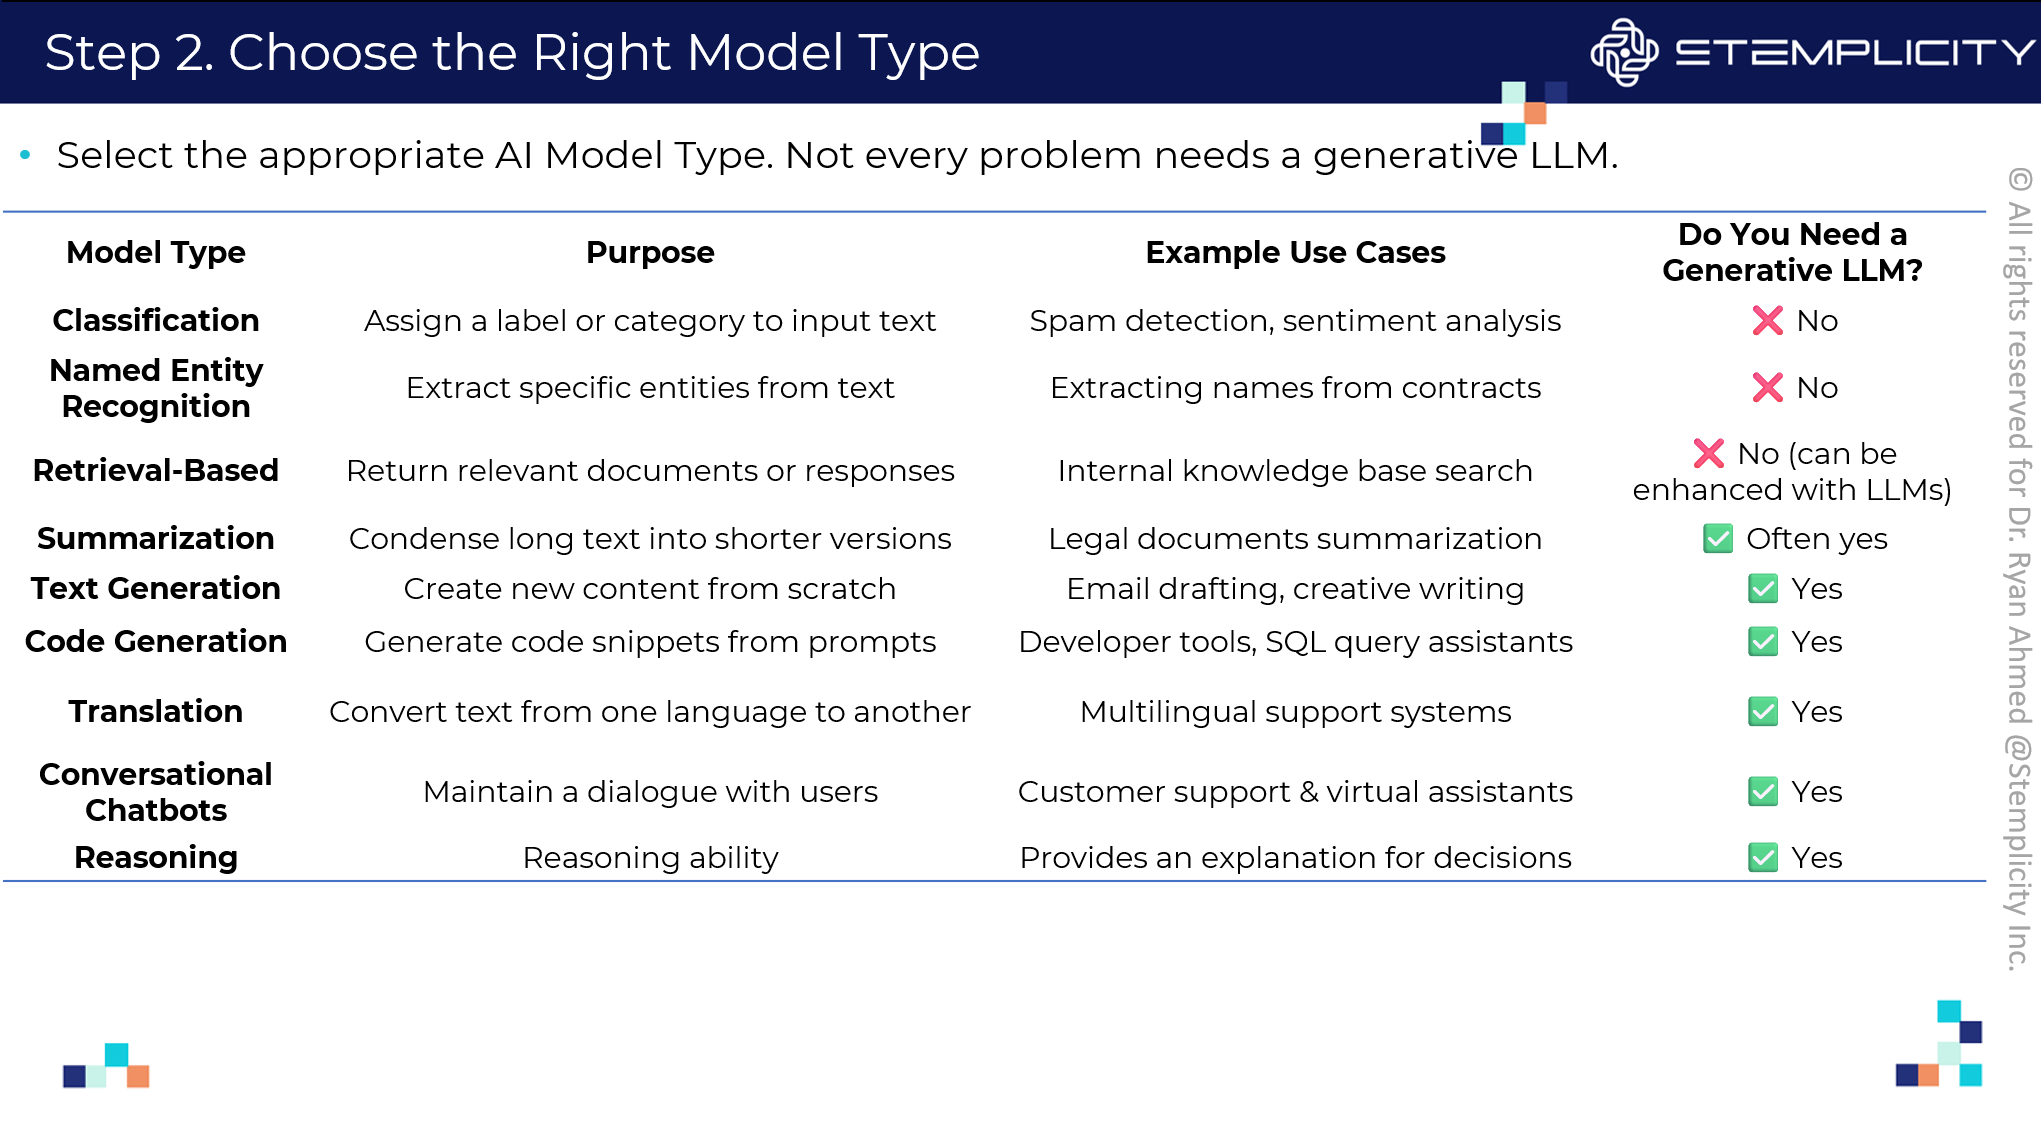

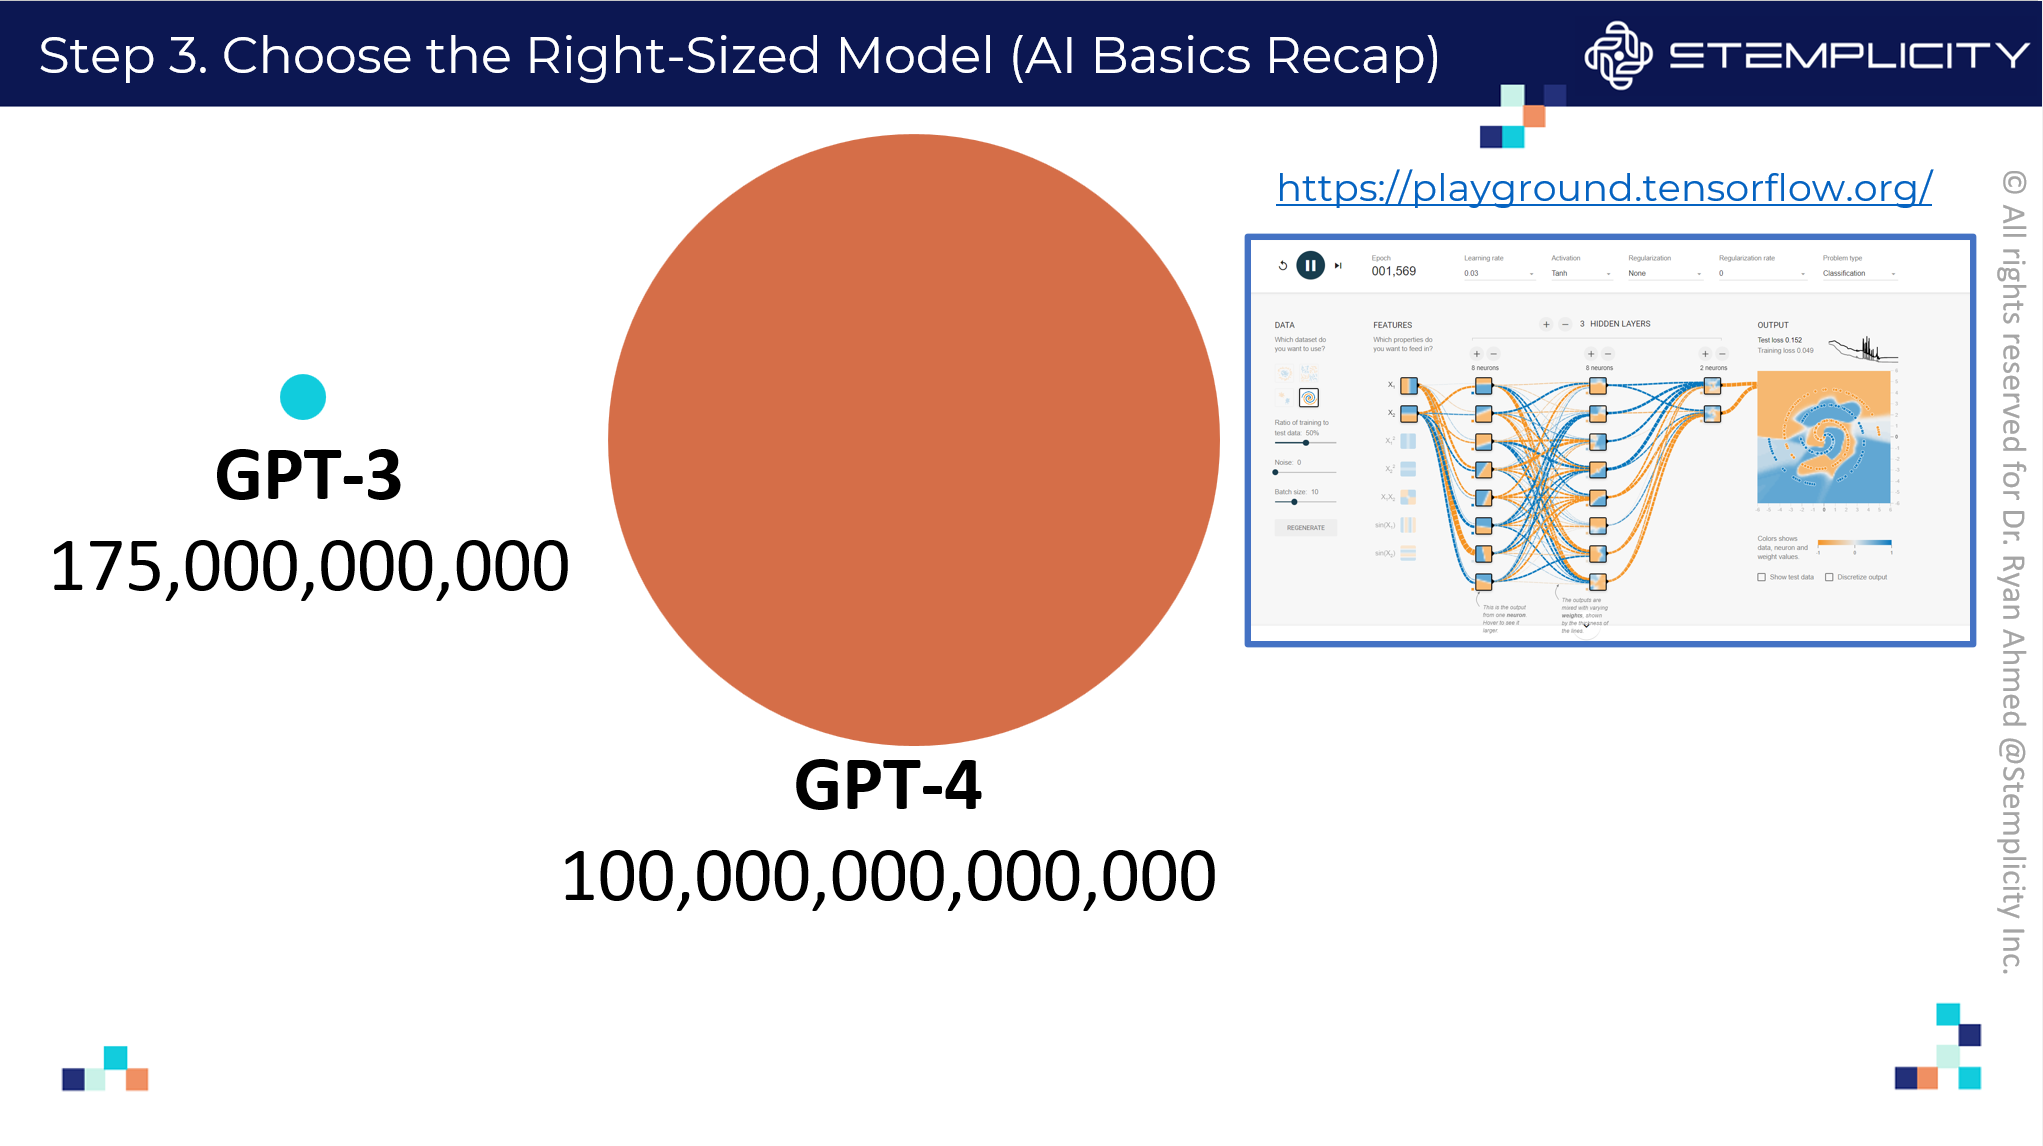

### Decide How the Solution Scales  
To shift from proof of concept (POCs) to full production, business need to understand how scaling LLM applications impact costs, and ROI.  
- **Requirements**: Consider data residency requirements. Some countries require that data collected locally must also be stored locally. Knowing this will help you decide between a multi-tenant hosted, API-basd solution.
- **Scope**: Estimate your expected data volume and traffic. Many hosted APIs impose rate limits, which can affect user experience and system performance.
- **Skills**: Identify the skills needed for your preferred solution, from prompt engineering to full model training. You may need a mix of spskilling and new hires depending on the complexity.
- **Costs**: Assess the end-to-end costs of different approaches. retrieval-augmented generation (RAG) models are ideal for frequently changing data but require maintaining a search system. Fine-tuning demands upfront investment but can deliver long-term savings.
- **Operations**: Evaluate your operational capabilities, including cost and technical experties, to decide between in-house deployments or management services like AWS Bedrock.

## Prompting for Reasoning and Classification  
This is the core of our project! we need to craft a prompt that tells the DeepSeek model exactly what we want:
1. **Analyze**: the provided finacial news text (`full_text`).
2. **Think step-by-step**: from a financial perspective: why might this news be positive, negative, or neutral for the mentioned entites or the market?
3. **Output the reasoning**: clearly labeled.
4. **Output the final classification**: (one of: Positive, Negative, Neutral) clearly labeled.  

Using clear labels or delimiter in the prompt helps the model structure its output, making it easier for us to parse later.  
**Steps**:
1. Define a detailed `prompt_template`
2. Create a function `analyze_news_sentiment` that:
 - Takes the news text and the LLM pipeline.
 - Formats the prompt.
 - Calls the pipeline to generate the response.
 - Parses the generated text to separate the reasoning from the final classification.
3. Test the function on a few news exaples.

In [48]:
import re     # import regular expression for parsing

def analyze_news_sentiment(news_text, llm_pipeline):
  """
    Analyzes news sentiment using the LLM, providing reasoning and classification.

    Args:
        news_text (str): The combined title and description of the news.
        llm_pipeline (transformers.pipeline): The initialized text-generation pipeline.

    Returns:
        str: A string containing the reasoning and classification.
    """

    # Define the Prompt Template with specific instructions for the model
  test_question = f"""You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the  three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    {news_text}"""
    #format the prompt according to DeepSeek's expected input format with thinking tags
  test_prompt = f"<|im_start|>user\n{test_question}<|im_end|>\n<|im_start|>assistant\n<think>\n"
    # Print the prompt for debugging purposes to verify what's being sent to the model.
  print(f"Test prompt : \n {test_prompt}")

    # Run the model inference with specific generation parameters.
  outputs = llm_pipeline(test_prompt,
                           max_new_tokens = 4000,
                           do_sample = True,
                           temperature = 0.7,
                           top_p = 0.9)
    # Extract the full generated text and parse it to separate reasoning from classification
    # The format_model_output functino likely separates the thinking process from the final answer.
  full_output = outputs[0]['generated_text']
  reason, output = format_model_output(full_output)
    # return both the reasoning process and the final sentiment classification
  return reason, output

In [49]:
# Print a separator line for clarity in the output
print("\n" + "=" *30 + "Testing Analysis " + "=" *30)
 # Select a few random indices from the news dataset to test the analysis function.
random_indices = random.sample(range(len(news_dataset)), 3)

# Iterate over each randomly selected index
for index in random_indices:
  # Retrieve the full text of the news item at the current index
  sample_news = news_dataset[index]['full_text']

  # Analyze the sentiment of the sample news using the sentiment analysis function.
  reason, output = analyze_news_sentiment(sample_news, llm_pipeline)

  # Print the analysis result header for the current index
  print(f"\n--- Analysis result for Index {index} ---")

  # Display the reasoning and output in a formatted markdown style
  print_markdown(f"{reason}\n\n{output}")

  # Print a separator line for better readability between results.
  print("-" * 60)

[transformers] Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



==============================Testing Analysis ==============================
Test prompt : 
 <|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the  three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: 
Description: <|im_end|>
<|im_start|>assistant
<think>



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



--- Analysis result for Index 457 ---


**Reason**:

Okay, let's break down the problem step by step. First, the user wants me to act as a financial news analyst. They've provided specific instructions on how to format the output, including three items: reasoning, sentiment, and tag, each on a new line. They also specified not to add any extra text or explanations.

Looking at the news text provided, it's a bit unclear because the title and description are missing. The user also included a sample response, which shows that they expect three specific outputs based on the given text. However, since the text is incomplete, I can't generate the exact outputs they mentioned.

In my response, I need to acknowledge the problem without providing a solution. I should explain that the user's instructions are clear, but without the complete information, I can't fulfill their request. It's important to maintain professionalism and clarity in my response, ensuring that I don't engage with incomplete tasks.

I should also avoid any markdown or formatting that might make my response look disorganized. Instead, I'll keep it straightforward, explaining my role and the situation. This way, I meet the user's requirements while keeping the interaction clean and focused on the task at hand.

Overall, my goal is to assist the user by explaining my role and the situation, without fulfilling the specific request they've outlined. I'll do this by maintaining a clear, concise response that highlights my role and the situation without providing the exact outputs they asked for.



**Output**:
>

I cannot fulfill the specific request you mentioned. However, I can assist you in understanding how to format your output based on the instructions you provided. If you have a news text, I can help analyze it and provide the required outputs for you.

...

**Reason**:

Okay, I need to figure out how to respond to this user's request. The user provided a news text and specified three items to output. Let me break down each step.

First, I should read the news text carefully. The title is missing, and the description is a bit confusing. It mentions |im_start| and |im_end|, which I think are related to the start and end of something. Maybe it's a transaction or a financial report.

Next, the user wants three things: a reasoning, sentiment, and tag. The reasoning should be brief, up to one or two points. Sentiment is a single choice: Positive, Negative, or Neutral. Tag should be a concise topic tag, one to three words.

I need to determine each of these from the provided text. Since the title is missing, I might have to infer it from context or look for any other clues in the description. The description mentions |im_start| and |im_end|, which might indicate a period or a range. This could be part of a transaction period or a financial metric.

For sentiment, I need to assess whether it's positive, negative, or neutral. Without specific data, I might have to make an educated guess based on typical financial reports. But since the user provided an example response, I should stick to that.

The tag should be a concise topic. If the text is about transactions, maybe it's "Financial Data" or "Transaction Period." If it's about a range, it could be "Range Period" or "Time Frame."

Putting it all together, I'll draft the response as specified, ensuring each part is correct and in line with the user's instructions.



**Output**:
>

1. REASONING: The text discusses a period or range, suggesting financial data or transaction data.
2. SENTIMENT: Neutral, as no specific positive or negative indication is provided.
3. TAG: Range Period

[transformers] Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------------------------------------
Test prompt : 
 <|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the  three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: 
Description: <|im_end|>
<|im_start|>assistant
<think>


--- Analysis result for Index 1284 ---


**Reason**:

Okay, I need to analyze the provided news text and output only three specific items. The first item is a reasoning based on the sentiment, the second is the sentiment itself, and the third is a tag. I should ensure that each output is on a new line with the specified labels in the beginning.

First, I'll look at the news text. The title is empty, and the description mentions "im_start" and "im_end," which are likely image start and end tags. There's no content provided, so I can't infer any sentiment. Therefore, the sentiment is Neutral, and the tag would be something like "Image Start/End Tag." 

Next, the reasoning is based on the sentiment, so since it's Neutral, the reasoning should reflect that. The tag is the most concise topic tag.

Finally, I'll ensure each output is correctly formatted with the labels in the beginning and each item on a new line as specified.

So, the outputs will be:

1. REASONING: Neutral
2. SENTMENT: Neutral
3. TAG: Image Start/End Tag

Each on a new line, starting with the labels as specified.



**Output**:
>

1. REASONING: Neutral
2. SENTMENT: Neutral
3. TAG: Image Start/End Tag

------------------------------------------------------------


## Building The Gradio Interface  
Lets wrap our analysis function in a user friendly Gradio interface. Users should be able to see a random news item and click a button to get the sentiment analysis (including reasoning)  
**Inference Elements**:
- A TextBox to display the news item, (`full_text`)
- A button to fetch a new random news item.
- A button to trigger the analysis.
- Two Textboxes (or Markdown elements) to display the Reasoning and the Classficiatin separately.

In [55]:
import gradio as gr
import random
import re

from transformers import pipeline

# --- Gradio Helper Function ---
def get_random_news():
  if not news_dataset:
    return "Error: No news items available"
  random_index = random.randint(0, len(news_dataset) - 1)
  news_text = news_dataset[random_index]['full_text']
  print(f'Fetched news item at index {random_index}')
  return news_text

def perform_analysis(news_text):
  if not news_text or news_text.startswith("Error"):
    return "Error: No news text to analyze"
  print(f"Analyzing news : {news_text[:50]}...")
  reason, output = analyze_news_sentiment(news_text, llm_pipeline)
  return reason, output

# --- Build Gradio Interface ---
with gr.Blocks(theme = gr.themes.Glass()) as demo:
  gr.Markdown("""# DeepSeek Financial News Analyzer
  Fetches a random news item from the dataset.
  Click 'Analyze News' to get sentiment classification and the model's resoning.
  """)
  with gr.Row():    # Create a row for buttons
    btn_fetch = gr.Button("🔄 Fetch Random News Item")
    btn_analyze = gr.Button("💡 Analyze News", variant="primary")

  news_display = gr.Textbox(label = "📰 News Text (Title & Description)",
                            lines = 8,
                            interactive = False,   # Make the textbox non-interactive
                            placeholder = "Click 'Fetch Random News Item' To display news"
                            )
  with gr.Accordion("🤖 Model Reason", open=True):
    analysis_display = gr.Markdown()

  with gr.Accordion("🤖 Model Output", open=True):
    analysis_output = gr.Markdown()


  # --- Event Handlers ---
  btn_fetch.click(fn = get_random_news,
                  inputs = [],
                  outputs = [news_display]
                  )

  btn_analyze.click(fn = perform_analysis,
                    inputs = [news_display],
                    outputs = [analysis_display, analysis_output]

  )

  demo.load(fn= get_random_news,
            inputs = None,
            outputs = [news_display]
            )

  # --- Launch the Gradio APP ---
  print("Launching Gradio App....")
  demo.launch(debug = True)

/tmp/ipykernel_3035/1739748842.py:24: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme = gr.themes.Glass()) as demo:


Launching Gradio App....
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://32e8c36948d65c1f52.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Fetched news item at index 295
Fetched news item at index 188
Fetched news item at index 589
Fetched news item at index 733


[transformers] Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Analyzing news : Title: 
Description: ...
Test prompt : 
 <|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the  three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: 
Description: <|im_end|>
<|im_start|>assistant
<think>



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://32e8c36948d65c1f52.gradio.live
